In [ ]:
!pip install -q mne

import os
import glob
import warnings
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, precision_recall_curve, auc

# Ẩn các cảnh báo hệ thống để màn hình output sạch sẽ
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
mne.set_log_level("ERROR")

print("Đã cấu hình xong thư viện!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 47.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.0 which is incompatible.
Đã cấu hình xong thư viện!


In [ ]:
# Đường dẫn trực tiếp tới thư mục dữ liệu đã được Kaggle giải nén sẵn
input_dir = "/kaggle/input/datasets/ledaihoangnguyentmu/sleep-edf-database-expanded-1-0-0-zip/sleep-edf-database-expanded-1.0.0"

# Kiểm tra xem đường dẫn có hoạt động chính xác không
if os.path.exists(input_dir):
    print("✅ Đã kết nối thành công tới bộ dữ liệu Sleep-EDF!")
    print("Các thư mục con sẵn sàng sử dụng:")
    
    # Liệt kê các file/thư mục bên trong để chắc chắn
    files = os.listdir(input_dir)
    for f in files:
        print(f" - {f}")
else:
    print("⚠️ Không tìm thấy thư mục dữ liệu, vui lòng kiểm tra lại đường dẫn.")

cassette_dfs = pd.read_csv(os.path.join(input_dir, "cassette.csv"))
telemetry_dfs = pd.read_csv(os.path.join(input_dir, "telemetry.csv"))
print("✅ Đã tải dữ liệu từ cassette.csv và telemetry.csv vào DataFrame!")

Mounted at /content/drive
Đang giải nén bộ dữ liệu...
🎉 Giải nén hoàn tất!


In [ ]:
# Cấu hình danh mục chuẩn
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
VALID_STAGES = ['Sleep stage W', 'Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R']
MAPPING_STAGES = {'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3, 'Sleep stage 4': 3, 'Sleep stage R': 4}
SEED = 42
KFOLD = 5

# --- KHỞI TẠO CÁC MÔ HÌNH THÍ NGHIỆM ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
}

results = {m: [] for m in models.keys()}
final_evaluation_data = {m: {'true': [], 'pred': []} for m in models.keys()}
file_majority_labels = [int(df['label'].mode().iloc[0]) for df in cassette_dfs]

def calculate_metrics_v2(y_true, y_pred, y_probs):
    # Tính Acc, Precision, F1 thông thường
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Binarize nhãn để tính PR-AUC cho đa lớp (5 lớp)
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4])

    # Tính PR-AUC Macro
    pr_auc_scores = []
    for i in range(5): 
        precision_curve, recall_curve, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        precision_recall_auc = auc(recall_curve, precision_curve)
        pr_auc_scores.append(precision_recall_auc)

    macro_pr_auc = np.mean(pr_auc_scores)

    return {
        'acc': acc,
        'precision': precision,
        'f1': f1,
        'pr_auc': macro_pr_auc
    }

In [ ]:
# --- VÒNG LẶP HUẤN LUYỆN CROSS-VALIDATION CHỐNG LEAKAGE ---
for fold, (train_idx, val_idx) in enumerate(skf.split(cassette_dfs, file_majority_labels)):
    print(f"\n⚡ Đang tính toán Fold {fold+1} / {KFOLD}..." )

    df_train_fold = pd.concat([cassette_dfs[i] for i in train_idx], ignore_index=True)
    df_test = pd.concat(telemetry_dfs, ignore_index=True)

    feature_cols = [c for c in df_train_fold.columns if c != 'label']
    X_train_raw, y_train = df_train_fold[feature_cols].values, df_train_fold['label'].values
    X_test_raw, y_test = df_test[feature_cols].values, df_test['label'].values

    pipeline_scaler = Pipeline([
        ('log1p', FunctionTransformer(np.log1p, validate=True)),
        ('scaler', StandardScaler())
    ])

    X_train = pipeline_scaler.fit_transform(X_train_raw)
    X_test = pipeline_scaler.transform(X_test_raw)

    # Tính sample weight cho XGBoost
    xgb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    for name, model in models.items():
        if name == 'XGBoost':
            model.fit(X_train, y_train, sample_weight=xgb_sample_weights)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)

        # Lưu metrics từng fold
        metrics = calculate_metrics_v2(y_test, preds, probs)
        results[name].append(metrics)

        # Tích lũy mảng cho Confusion Matrix tổng
        final_evaluation_data[name]['true'].extend(y_test)
        final_evaluation_data[name]['pred'].extend(preds)

        print('Model: ', name, '| acc: ', metrics['acc'], '| precision: ', metrics['precision'], '| f1 score: ', metrics['f1'], '| pr_auc: ', metrics['pr_auc'])

print("\n🎉 Vòng lặp tính toán hoàn tất! Đang xuất đồ thị báo cáo...")


⚡ Đang tính toán Fold 1 /  153 ...

⚡ Đang tính toán Fold 2 /  153 ...

⚡ Đang tính toán Fold 3 /  153 ...

⚡ Đang tính toán Fold 4 /  153 ...

⚡ Đang tính toán Fold 5 /  153 ...

🎉 Vòng lặp tính toán hoàn tất! Đang xuất đồ thị báo cáo...



📊 DETAILED AVERAGE STATISTICS TABLE:


,acc,precision,f1,roc_auc
Model,,,,
Random Forest,0.5026,0.5319,0.3293,0.8539
XGBoost,0.5006,0.4976,0.4491,0.8386


<Figure size 900x500 with 0 Axes>

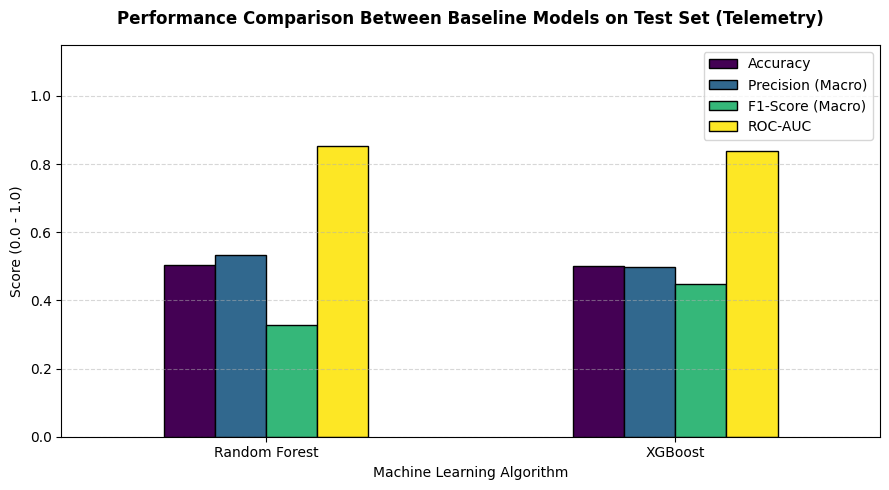

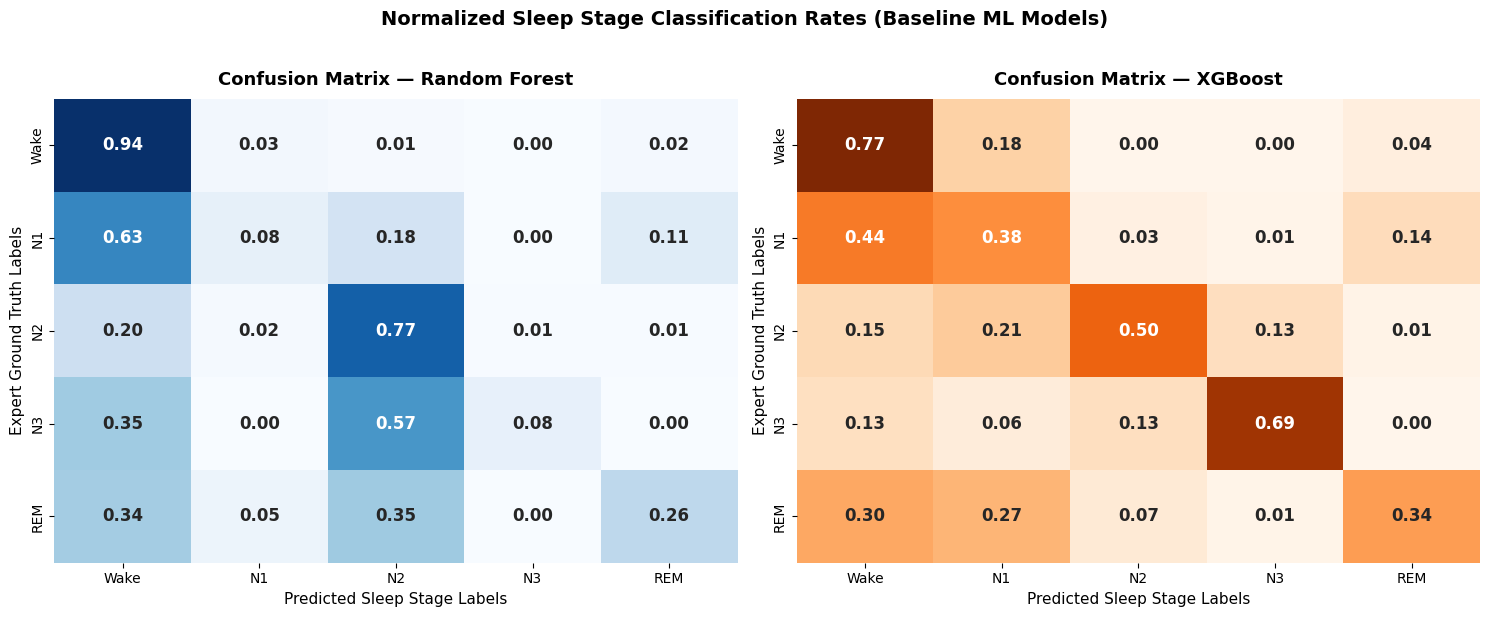

In [ ]:
print("\n📈 CHI TIẾT KẾT QUẢ QUA CÁC FOLDS:")

fold_records = []
for model_name, folds_list in results.items():
    for fold_idx, metrics in enumerate(folds_list):
        rec = metrics.copy()
        rec['Model'] = model_name
        rec['Fold'] = f"Fold {fold_idx + 1}"
        fold_records.append(rec)

df_folds = pd.DataFrame(fold_records)

# Hiển thị bảng chi tiết từng fold
for model_name in results.keys():
    print(f"\n➔ Model: {model_name}")
    df_model_folds = df_folds[df_folds['Model'] == model_name].set_index('Fold')
    display(df_model_folds[['acc', 'precision', 'f1', 'pr_auc']].round(4))

# Hiển thị bảng trung bình
print("\n📊 AVERAGE EVALUATION RESULTS ON INDEPENDENT TEST SET (TELEMETRY):")
df_summary = df_folds.groupby('Model')[['acc', 'precision', 'f1', 'pr_auc']].mean()
display(df_summary.round(4))


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics_to_plot = ['acc', 'precision', 'f1']
existing_folds = df_folds['Fold'].unique()

# Đồ thị 1: So sánh Acc, Precision, F1
for model_name in results.keys():
    df_m = df_folds[df_folds['Model'] == model_name]
    for metric in metrics_to_plot:
        axes[0].plot(
            df_m['Fold'], df_m[metric], 
            marker='o', linestyle='-', label=f"{model_name} - {metric.upper()}",
            alpha=0.8
        )

axes[0].set_title("Performance Metrics across Folds", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Score (0.0 - 1.0)")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower left', bbox_to_anchor=(0, -0.32), ncol=2)


# --- 3. VẼ BIỂU ĐỒ ĐƯỜNG RIÊNG CHO PR_AUC ---
for model_name in results.keys():
    df_m = df_folds[df_folds['Model'] == model_name]
    axes[1].plot(
        df_m['Fold'], df_m['pr_auc'], 
        marker='s', markersize=8, linestyle='--', linewidth=2,
        label=f"{model_name} - PR_AUC"
    )

axes[1].set_title("Target Metric (PR_AUC) across Folds", fontweight='bold', fontsize=12)
axes[1].set_ylabel("AUC Score")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right', bbox_to_anchor=(1, -0.22))

plt.tight_layout()
plt.show()


# --- 4. VẼ CONFUSION MATRIX CHUẨN (Khắc phục hoàn toàn lỗi trích xuất mẫu) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

num_actual_folds = len(existing_folds)

for idx, model_name in enumerate(['Simple ANN', 'BiLSTM']):
    # Tìm fold có F1-score cao nhất của model này
    df_m = df_folds[df_folds['Model'] == model_name]
    best_fold_idx = df_m['f1'].idxmax()
    best_fold_num = df_m.loc[best_fold_idx, 'Fold']
    
    # Tính chính xác kích thước tập test của 1 fold đơn lẻ
    total_test_samples = len(final_evaluation_data[model_name]['true']) // num_actual_folds
    
    fold_number = int(best_fold_num.split()[-1]) - 1 # Chuyển đổi chữ "Fold X" thành chỉ số index
    start_pos = fold_number * total_test_samples
    end_pos = start_pos + total_test_samples
    
    # Trích xuất chuẩn xác phân đoạn dữ liệu của fold tốt nhất
    y_true_best = final_evaluation_data[model_name]['true'][start_pos:end_pos]
    y_pred_best = final_evaluation_data[model_name]['pred'][start_pos:end_pos]

    # Tính toán Confusion Matrix
    cm = confusion_matrix(y_true_best, y_pred_best, labels=[0, 1, 2, 3, 4])
    
    # Chuẩn hóa theo hàng dòng (True labels), phòng tránh lỗi chia cho 0 bằng giá trị eps nhỏ
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Purples",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=axes[idx], cbar=False
    )

    axes[idx].set_title(
        f"CM - {model_name} ({best_fold_num} - Best F1)", 
        fontweight='bold', fontsize=12
    )
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()